# Experimento 3 — LSTM-Quantile: Predicción Probabilística

**Objetivo:** Entrenar un LSTM con cabeza de regresión por cuantiles sobre TALASOL
y evaluar la calibración del intervalo de predicción.

**Modelo:** `LSTMQuantileForecaster` — misma arquitectura que el LSTM de Exp 1/2,
pero con 5 salidas ordenadas por cuantil (0.05, 0.25, 0.50, 0.75, 0.95).

**Métricas:** MAE/RMSE/R² (mediana), Pinball loss, CRPS, Coverage 50%/90%.


In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ============================================================================
# CELDA COLAB — Ejecutar PRIMERO en Google Colab (saltar en local)
# ============================================================================
# 1. Monta Google Drive:
#    from google.colab import drive; drive.mount('/content/drive')
# 2. Navega al repositorio:
#    import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')
# 3. Ejecuta esta celda (torch y demás ya están preinstalados en Colab)
#
# PRERREQUISITO: ejecutar 00_eda_preprocessing.ipynb para crear data/processed/
# ============================================================================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Colab detectado — torch ya preinstalado, sin dependencias extra.')
else:
    print('Entorno local — sin instalaciones adicionales.')


Colab detectado — torch ya preinstalado, sin dependencias extra.


In [3]:
# ── Keep-alive: evita desconexión de Colab durante entrenamientos largos ───────
# Ejecutar ANTES de iniciar el entrenamiento. El intervalo hace clic en el botón
# "Conectar" de Colab cada 60 s para mantener la sesión activa.
# En entorno local esta celda no tiene efecto (el JS solo se ejecuta en Colab).
try:
    from google.colab import output
    output.eval_js("""
        function clickConnect() {
            const btn = document.querySelector("colab-connect-button");
            if (btn) btn.click();
        }
        setInterval(clickConnect, 60000);
        console.log("Keep-alive activado: clic cada 60s en el botón Conectar.");
    """)
    print("Keep-alive activado.")
except Exception:
    print("No estamos en Colab — keep-alive omitido.")

Keep-alive activado.


In [4]:
# ── Celda 0: Setup ────────────────────────────────────────────────────────────
import sys
import pathlib as _pl

# Detección robusta del repo root: busca la carpeta que contiene src/ y data/processed/
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f'No se encontró src/ ni data/processed/. cwd={_pl.Path.cwd()}\n'
        'En Colab: monta Drive, ejecuta os.chdir() al repo '
        'y corre 00_eda_preprocessing.ipynb primero.'
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# Config Exp 3 LSTM
from ex3_probabilistic.ex3_lstm_config import (
    PLANTA_TARGET, QUANTILES, SMOKE_TEST, SMOKE_MAX_ROWS,
    DATA_DIR, RESULTS_DIR, CHECKPOINTS_DIR, DEVICE,
    SEQ_LENGTH, FEATURE_COLS, FUTURE_FEATURE_COLS, LAG_STEPS,
    N_FEATURES_TOTAL, MODEL_CFG,
)

# Modelos y evaluación
from lstm_model import LSTMQuantileForecaster, LSTMQuantileTrainer
from evaluation import ForecastEvaluator

# Semilla de reproducibilidad
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Crear directorios de salida
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'\n── Configuración Exp 3 LSTM-Quantile ──')
print(f'  Planta    : {PLANTA_TARGET}')
print(f'  Cuantiles : {QUANTILES}')
print(f'  Device    : {DEVICE}')
print(f'  Smoke test: {SMOKE_TEST}')
print(f'  Seq length: {SEQ_LENGTH} h')
print(f'  n_features: {N_FEATURES_TOTAL}')
print(f'  Results   : {RESULTS_DIR}')


[ex3_lstm] Entorno: Google Colab | Device: cuda (Tesla T4)

── Configuración Exp 3 LSTM-Quantile ──
  Planta    : TALASOL
  Cuantiles : [0.05, 0.25, 0.5, 0.75, 0.95]
  Device    : cuda
  Smoke test: False
  Seq length: 48 h
  n_features: 17
  Results   : /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/lstm


In [5]:
# ── Celda 1: Carga de datos ───────────────────────────────────────────────────
from data_loaders import SolarSequenceDataset
from models import SolarScaler
from torch.utils.data import DataLoader

def load_split(split: str) -> pd.DataFrame:
    """Carga el CSV de un split y filtra por TALASOL."""
    path = DATA_DIR / f'{split}.csv'
    df = pd.read_csv(path, parse_dates=['timestamp_utc'])
    df = df[df['planta_nombre'] == PLANTA_TARGET].copy()
    df = df.sort_values('timestamp_utc').reset_index(drop=True)
    return df

df_train_full = load_split('train')
df_val_full   = load_split('val')
df_test_full  = load_split('test')

print(f'Columnas: {list(df_train_full.columns[:10])}...')
print(f'Train: {len(df_train_full):,} | Val: {len(df_val_full):,} | Test: {len(df_test_full):,}')

# ── Escaladores ajustados SOLO sobre train ────────────────────────────────────
# scaler_y: SolarScaler del target, ajustado sobre train
# scaler_x: SequenceScaler de features, se extrae de ds_train tras crearlo
# IMPORTANTE: val y test deben usar los MISMOS scalers que train para que
# los valores normalizados tengan el mismo significado en los tres splits.
scaler_y = SolarScaler()
scaler_y.fit(df_train_full['produccion'].values)
print(f'SolarScaler: mean={scaler_y.mean_:.2f}, std={scaler_y.std_:.2f}')

# Capacidad efectiva: máximo observado en train (cota física para el clip)
CAPACITY_KW = float(df_train_full['produccion'].max())
print(f'Capacidad efectiva (max train): {CAPACITY_KW:.1f} unidades')

df_train = df_train_full.head(SMOKE_MAX_ROWS) if SMOKE_TEST else df_train_full

# ── Crear ds_train primero (ajusta scaler_x internamente) ─────────────────────
ds_train = SolarSequenceDataset(
    df=df_train,
    planta_nombre=PLANTA_TARGET,
    feature_cols=FEATURE_COLS,
    future_feature_cols=FUTURE_FEATURE_COLS,
    lag_steps=LAG_STEPS,
    target_col='produccion',
    seq_length=SEQ_LENGTH,
    scaler_x=None,      # se ajusta sobre train
    scaler_y=scaler_y,
)
# Extraer scaler_x ajustado sobre train para reutilizarlo
scaler_x_train = ds_train.scaler_x

# ── Val y test: reusan los scalers de train ───────────────────────────────────
ds_val = SolarSequenceDataset(
    df=df_val_full,
    planta_nombre=PLANTA_TARGET,
    feature_cols=FEATURE_COLS,
    future_feature_cols=FUTURE_FEATURE_COLS,
    lag_steps=LAG_STEPS,
    target_col='produccion',
    seq_length=SEQ_LENGTH,
    scaler_x=scaler_x_train,   # mismo scaler que train
    scaler_y=scaler_y,
)
ds_test = SolarSequenceDataset(
    df=df_test_full,
    planta_nombre=PLANTA_TARGET,
    feature_cols=FEATURE_COLS,
    future_feature_cols=FUTURE_FEATURE_COLS,
    lag_steps=LAG_STEPS,
    target_col='produccion',
    seq_length=SEQ_LENGTH,
    scaler_x=scaler_x_train,   # mismo scaler que train
    scaler_y=scaler_y,
)

print(f'\nn_features_total: {ds_train.n_features_total} (esperado: {N_FEATURES_TOTAL})')
assert ds_train.n_features_total == N_FEATURES_TOTAL, \
    f'Mismatch: {ds_train.n_features_total} != {N_FEATURES_TOTAL}'

BS = MODEL_CFG['batch_size']
dl_train = DataLoader(ds_train, batch_size=BS, shuffle=True,  drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BS, shuffle=False, drop_last=False)
dl_test  = DataLoader(ds_test,  batch_size=BS, shuffle=False, drop_last=False)

print(f'DataLoaders: train={len(dl_train)} batches | val={len(dl_val)} | test={len(dl_test)}')


Columnas: ['timestamp_utc', 'hour_number', 'produccion', 'temperature_2m', 'direct_normal_irradiance', 'shortwave_radiation', 'global_tilted_irradiance', 'wind_speed_10m', 'cloud_cover', 'cloud_cover_low']...
Train: 8,978 | Val: 1,130 | Test: 1,487
SolarScaler: mean=227.53, std=269.76
Capacidad efectiva (max train): 901.6 unidades

n_features_total: 17 (esperado: 17)
DataLoaders: train=131 batches | val=15 | test=23


LSTMQuantileForecaster: 15,734 parámetros
Output shape: (batch, 5) = [0.05, 0.25, 0.5, 0.75, 0.95]


Training LSTM-Quantile:  32%|███▎      | 26/80 [00:31<01:05,  1.21s/it, best=0.0819, lr=1.0e-03, train=0.0292, val=0.0851]



Early stopping época 27

✓ Completado  |  best val_loss: 0.081917
Tiempo de entrenamiento: 0.5 min (31 s)
✓ Checkpoint guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex3_probabilistic/lstm/lstm_quantile_talasol.pt


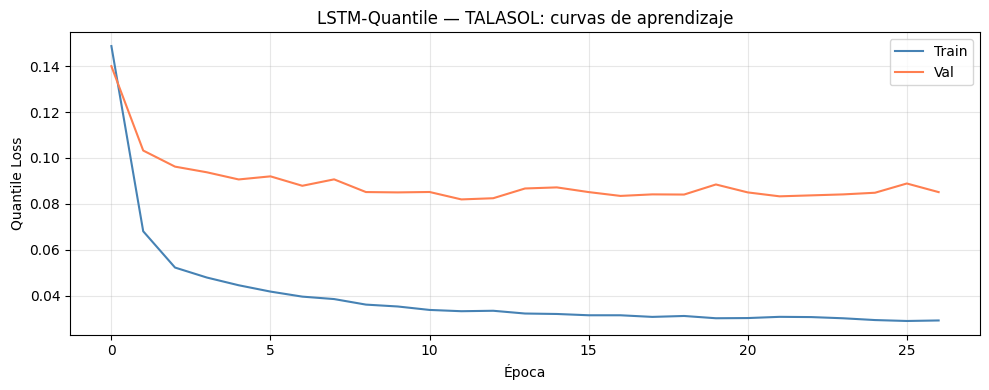

Best val_loss: 0.081917


In [6]:
# ── Celda 2: Entrenamiento ────────────────────────────────────────────────────
import time

model = LSTMQuantileForecaster(
    n_features        = N_FEATURES_TOTAL,
    n_future_features = len(FUTURE_FEATURE_COLS),
    hidden_size       = MODEL_CFG['hidden_size'],
    num_layers        = MODEL_CFG['num_layers'],
    dropout           = MODEL_CFG['dropout'],
    noise_std         = MODEL_CFG['noise_std'],
    n_quantiles       = MODEL_CFG['n_quantiles'],
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'LSTMQuantileForecaster: {n_params:,} parámetros')
print(f'Output shape: (batch, {MODEL_CFG["n_quantiles"]}) = {QUANTILES}')

ckpt_path = CHECKPOINTS_DIR / 'lstm_quantile_talasol.pt'

_resumed = False
if ckpt_path.exists():
    try:
        # ── RESUME: cargar checkpoint y saltar entrenamiento ──────────────────────
        print(f'\n[2/6] Checkpoint encontrado → skip entrenamiento')
        print(f'  {ckpt_path}')
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
        trainer = LSTMQuantileTrainer(
            model         = model,
            quantiles     = QUANTILES,
            device        = DEVICE,
            learning_rate = MODEL_CFG['lr'],
        )
        training_time_s = 0.0
        print('[2/6] OK (desde checkpoint)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        ckpt_path.unlink(missing_ok=True)
if not _resumed:
    # ── TRAIN: entrenamiento completo ─────────────────────────────────────────
    trainer = LSTMQuantileTrainer(
        model         = model,
        quantiles     = QUANTILES,
        device        = DEVICE,
        learning_rate = MODEL_CFG['lr'],
    )

    t0 = time.time()
    trainer.fit(
        train_loader = dl_train,
        val_loader   = dl_val,
        epochs       = MODEL_CFG['max_epochs'],
        patience     = MODEL_CFG['patience'],
        verbose      = True,
    )
    training_time_s = time.time() - t0
    print(f'Tiempo de entrenamiento: {training_time_s/60:.1f} min ({training_time_s:.0f} s)')

    # Guardar checkpoint en Google Drive (persistente entre sesiones)
    torch.save(model.state_dict(), ckpt_path)
    print(f'✓ Checkpoint guardado: {ckpt_path}')

    # Curvas de aprendizaje
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(trainer.train_losses, label='Train', color='steelblue', lw=1.5)
    ax.plot(trainer.val_losses,   label='Val',   color='coral',     lw=1.5)
    ax.set_xlabel('Época'); ax.set_ylabel('Quantile Loss')
    ax.set_title(f'LSTM-Quantile — {PLANTA_TARGET}: curvas de aprendizaje')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures' / 'learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Best val_loss: {min(trainer.val_losses):.6f}')

In [7]:
# ── Celda 3: Métricas de punto (mediana q50) ──────────────────────────────────
# Predicciones en escala normalizada
y_true_sc, q_preds_sc = trainer.predict(dl_test)

# Índice del cuantil mediano
q50_idx = QUANTILES.index(0.50) if 0.50 in QUANTILES else len(QUANTILES) // 2

# Inversión a escala original
y_true_kw  = scaler_y.inverse_transform(y_true_sc)
q_preds_kw = np.column_stack([
    scaler_y.inverse_transform(q_preds_sc[:, i])
    for i in range(len(QUANTILES))
])

# Clip a [0, CAPACITY_KW]: restricción física (producción ≥ 0, ≤ capacidad)
y_true_kw  = np.clip(y_true_kw,  0, CAPACITY_KW)
q_preds_kw = np.clip(q_preds_kw, 0, CAPACITY_KW)

y_pred_median = q_preds_kw[:, q50_idx]

# Métricas de punto
metrics_point = ForecastEvaluator.calculate_metrics(
    y_true=y_true_kw,
    y_pred=y_pred_median,
    planta_nombre=PLANTA_TARGET,
)
print('\n── Métricas de punto (mediana q50) ──')
for k, v in metrics_point.items():
    if isinstance(v, float):
        print(f'  {k:12s}: {v:.4f}')
    else:
        print(f'  {k:12s}: {v}')



── Métricas de punto (mediana q50) ──
  planta      : TALASOL
  n_samples   : 1439
  MAE         : 76.56024932861328
  RMSE        : 163.8874969482422
  MAPE        : 76.69319152832031
  R2          : 0.2908157706260681


In [8]:
# ── Celda 4: Métricas probabilísticas ─────────────────────────────────────────
metrics_prob = ForecastEvaluator.calculate_probabilistic_metrics(
    y_true=y_true_kw,
    q_preds=q_preds_kw,
    quantiles=QUANTILES,
)

print('── Métricas probabilísticas ──')
for k, v in metrics_prob.items():
    if isinstance(v, float):
        print(f'  {k:28s}: {v:.4f}')
    else:
        print(f'  {k:28s}: {v}')

print(f'\n  Coverage ideal 50%: 0.50  →  obtenido: {metrics_prob["coverage_50"]:.3f}')
print(f'  Coverage ideal 90%: 0.90  →  obtenido: {metrics_prob["coverage_90"]:.3f}')


── Métricas probabilísticas ──
  pinball_005                 : 4.8239
  pinball_025                 : 21.5733
  pinball_050                 : 38.2801
  pinball_075                 : 50.1728
  pinball_095                 : 46.4718
  CRPS                        : 32.2644
  coverage_50                 : 0.7415
  interval_width_50_mean      : 21.8037
  coverage_90                 : 0.7755
  interval_width_90_mean      : 58.2070

  Coverage ideal 50%: 0.50  →  obtenido: 0.741
  Coverage ideal 90%: 0.90  →  obtenido: 0.776


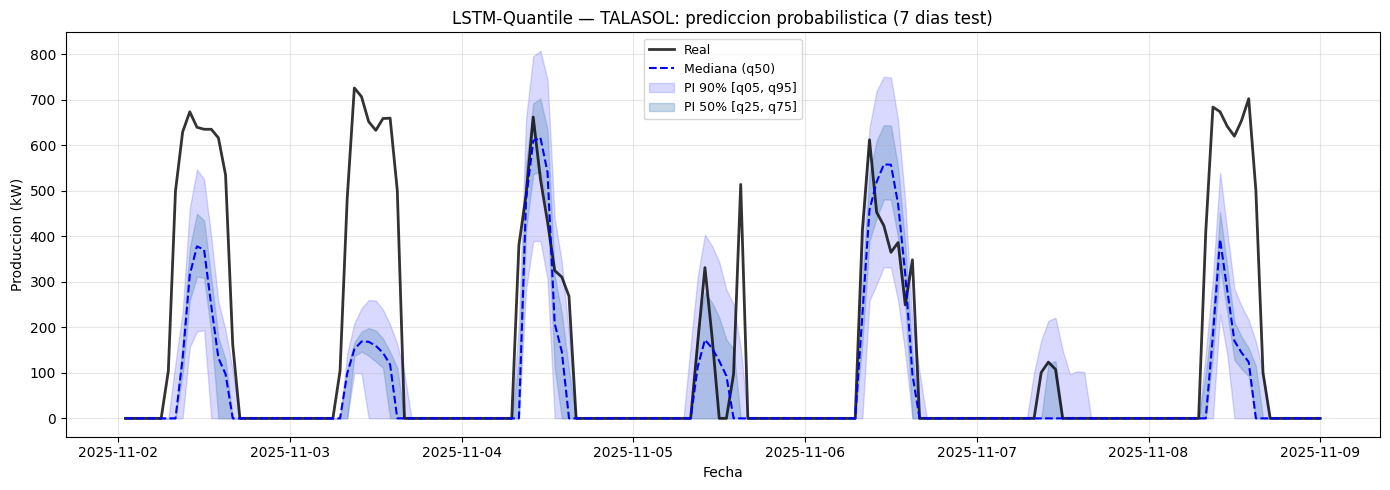

✓ Figura guardada: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/lstm/figures/calibration.png


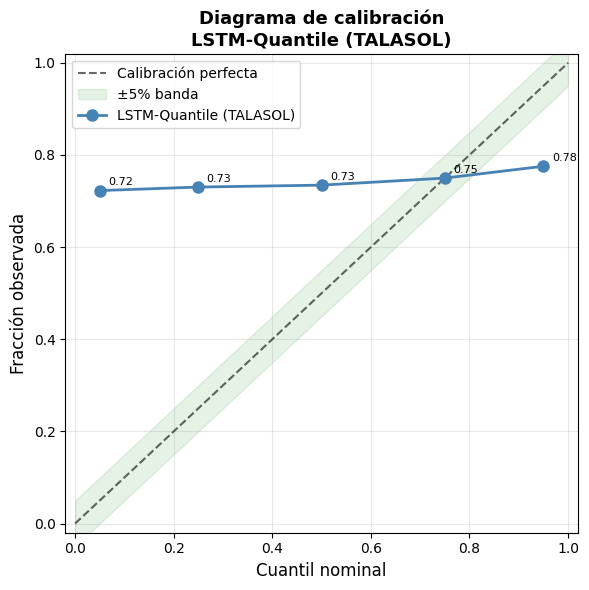

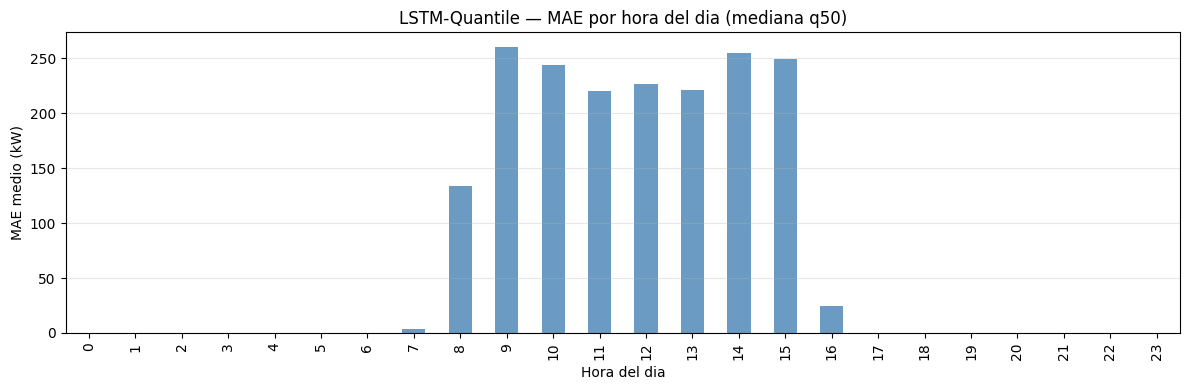

In [9]:
# ── Celda 5: Visualizaciones ──────────────────────────────────────────────────
# Timestamps del test alineados con valid_indices: solo ventanas válidas.
# ds_test.timestamps[SEQ_LENGTH:] tendría len(df_test)-SEQ_LENGTH entradas,
# pero ds_test puede tener menos si hay filas con valid_data=False en test.
# La forma correcta es reconstruir los timestamps desde valid_indices.
timestamps_test = np.array([
    ds_test.timestamps[idx + ds_test.seq_length]
    for idx in ds_test.valid_indices
])

# ── 5a: Time series con bandas de predicción ──────────────────────────────────
n_dias = 7
n_show = min(24 * n_dias, len(y_true_kw))

fig, ax = plt.subplots(figsize=(14, 5))

ts = timestamps_test[:n_show]
ax.plot(ts, y_true_kw[:n_show], 'k-',   lw=2, label='Real', alpha=0.8)
ax.plot(ts, q_preds_kw[:n_show, q50_idx], 'b--', lw=1.5, label='Mediana (q50)')

ax.fill_between(ts,
    q_preds_kw[:n_show, QUANTILES.index(0.05)],
    q_preds_kw[:n_show, QUANTILES.index(0.95)],
    alpha=0.15, color='blue', label='PI 90% [q05, q95]')

ax.fill_between(ts,
    q_preds_kw[:n_show, QUANTILES.index(0.25)],
    q_preds_kw[:n_show, QUANTILES.index(0.75)],
    alpha=0.3, color='steelblue', label='PI 50% [q25, q75]')

ax.set_xlabel('Fecha'); ax.set_ylabel('Produccion (kW)')
ax.set_title(f'LSTM-Quantile — {PLANTA_TARGET}: prediccion probabilistica ({n_dias} dias test)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'timeseries_pi.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5b: Diagrama de calibración ───────────────────────────────────────────────
ForecastEvaluator.plot_calibration(
    y_true=y_true_kw,
    q_preds=q_preds_kw,
    quantiles=QUANTILES,
    model_name='LSTM-Quantile (TALASOL)',
    save_path=str(RESULTS_DIR / 'figures' / 'calibration.png'),
)

# ── 5c: Error por hora del día (mediana) ──────────────────────────────────────
df_test_res = pd.DataFrame({
    'timestamp': pd.to_datetime(timestamps_test),
    'y_true': y_true_kw,
    'y_pred': y_pred_median,
})
df_test_res['hora'] = df_test_res['timestamp'].dt.hour
df_test_res['mae_hora'] = np.abs(df_test_res['y_true'] - df_test_res['y_pred'])

mae_by_hour = df_test_res.groupby('hora')['mae_hora'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
mae_by_hour.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Hora del dia'); ax.set_ylabel('MAE medio (kW)')
ax.set_title('LSTM-Quantile — MAE por hora del dia (mediana q50)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'mae_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

── Análisis de Sharpness — LSTM-Quantile ──
  Ancho medio PI 90%: 58.21 kW
  Ancho medio PI 50%: 21.80 kW
  Ancho máx  PI 90%: 474.88 kW  (hora 12h)
  Ancho min  PI 90% (>0): 92.67 kW


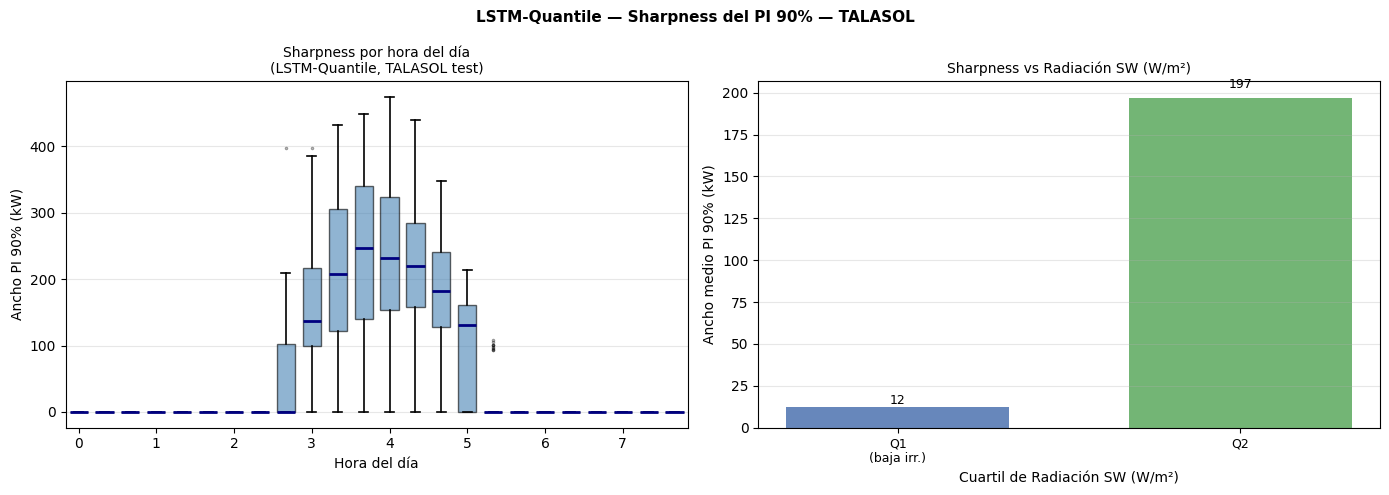

  Guardado: sharpness_analysis.png


In [10]:
# ── Celda 5b: Análisis de sharpness (amplitud de intervalos de predicción) ────
# La sharpness (nitidez) mide cuán estrechos son los intervalos de predicción.
# Un modelo ideal es calibrado Y afilado: cobertura correcta + intervalos estrechos.
# Analizamos cómo varía el ancho del PI 90% según:
#   1. Hora del día (patrón diurno solar)
#   2. Cuartil de irradiancia / nubosidad (proxy de condiciones atmosféricas)

_i05 = QUANTILES.index(0.05)
_i95 = QUANTILES.index(0.95)
_i25 = QUANTILES.index(0.25)
_i75 = QUANTILES.index(0.75)

_interval_90 = q_preds_kw[:, _i95] - q_preds_kw[:, _i05]   # ancho PI 90%
_interval_50 = q_preds_kw[:, _i75] - q_preds_kw[:, _i25]   # ancho PI 50%

_ts_sharp  = pd.DatetimeIndex(pd.to_datetime(timestamps_test))
_hours_sh  = _ts_sharp.hour

print('── Análisis de Sharpness — LSTM-Quantile ──')
print(f'  Ancho medio PI 90%: {_interval_90.mean():.2f} kW')
print(f'  Ancho medio PI 50%: {_interval_50.mean():.2f} kW')
print(f'  Ancho máx  PI 90%: {_interval_90.max():.2f} kW  '
      f'(hora {_hours_sh[np.argmax(_interval_90)]:02d}h)')
print(f'  Ancho min  PI 90% (>0): '
      f'{_interval_90[_interval_90 > 0].min():.2f} kW')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Boxplot del ancho PI 90% por hora del día ───────────────────────
_df_sharp = pd.DataFrame({'hora': _hours_sh, 'PI90': _interval_90})
_horas_u  = sorted(_df_sharp['hora'].unique())
_boxes    = [_df_sharp.loc[_df_sharp['hora'] == h, 'PI90'].values for h in _horas_u]

axes[0].boxplot(_boxes, positions=_horas_u, widths=0.7,
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='navy', lw=2),
                flierprops=dict(marker='.', markersize=3, alpha=0.4),
                whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2))
axes[0].set_xlabel('Hora del día', fontsize=10)
axes[0].set_ylabel('Ancho PI 90% (kW)', fontsize=10)
axes[0].set_title('Sharpness por hora del día\n(LSTM-Quantile, TALASOL test)', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(range(0, 24, 3))

# ── Panel 2: Ancho PI 90% por cuartil de irradiancia (o nubosidad) ───────────
_proxy_col = next((c for c in ['ghi', 'shortwave_radiation', 'cloud_cover']
                   if c in df_test_full.columns), None)

if _proxy_col is not None:
    # Alinear df_test_full con timestamps del test via merge.
    # Normalizar ambas columnas a timezone-naive para evitar conflictos tz.
    _ts_lkp = pd.DataFrame({
        'timestamp_utc': pd.to_datetime(timestamps_test).tz_localize(None),
        'PI90': _interval_90,
    })
    _df_lkp = df_test_full[['timestamp_utc', _proxy_col]].copy()
    _df_lkp['timestamp_utc'] = pd.to_datetime(_df_lkp['timestamp_utc']).dt.tz_localize(None)
    _merged = _ts_lkp.merge(_df_lkp, on='timestamp_utc', how='left')
    _proxy_vals = _merged[_proxy_col].fillna(0).values

    _proxy_label = {'ghi':                 'GHI (W/m²)',
                    'shortwave_radiation':  'Radiación SW (W/m²)',
                    'cloud_cover':          'Cobertura nubosa (%)'}[_proxy_col]
    _q_labels_full = (['Q1\n(baja irr.)', 'Q2', 'Q3', 'Q4\n(alta irr.)']
                      if _proxy_col != 'cloud_cover' else
                      ['Q1\n(despejado)', 'Q2', 'Q3', 'Q4\n(nublado)'])

    # labels=False: devuelve índices enteros (0-based); duplicates='drop' puede
    # producir menos de 4 bins cuando hay muchos ceros (horas nocturnas).
    _quartiles = pd.qcut(_proxy_vals, q=4, labels=False, duplicates='drop')
    _n_bins    = int(np.nanmax(_quartiles[~np.isnan(_quartiles)])) + 1
    _q_labels  = _q_labels_full[:_n_bins]

    _df_q    = pd.DataFrame({'quartile': _quartiles, 'PI90': _interval_90})
    _sharp_q = _df_q.groupby('quartile')['PI90'].mean()

    _colors_q = ['#4C72B0', '#5BA85D', '#DD8452', '#C44E52']
    _bars = axes[1].bar(range(1, _n_bins + 1), _sharp_q.values,
                        color=_colors_q[:_n_bins], alpha=0.85, width=0.65)
    for _bar, _v in zip(_bars, _sharp_q.values):
        axes[1].text(_bar.get_x() + _bar.get_width() / 2,
                     _bar.get_height() * 1.02, f'{_v:.0f}',
                     ha='center', va='bottom', fontsize=9)
    axes[1].set_xlabel(f'Cuartil de {_proxy_label}', fontsize=10)
    axes[1].set_ylabel('Ancho medio PI 90% (kW)', fontsize=10)
    axes[1].set_title(f'Sharpness vs {_proxy_label}', fontsize=10)
    axes[1].set_xticks(range(1, _n_bins + 1))
    axes[1].set_xticklabels(_q_labels, fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')
    del _ts_lkp, _df_lkp, _merged, _proxy_vals, _quartiles, _df_q, _sharp_q, _bars
else:
    axes[1].text(0.5, 0.5,
                 'ghi / shortwave_radiation / cloud_cover\nno disponible en df_test_full',
                 ha='center', va='center', transform=axes[1].transAxes,
                 fontsize=11, color='gray')
    axes[1].set_title('Sharpness vs irradiancia', fontsize=10)

plt.suptitle(f'LSTM-Quantile — Sharpness del PI 90% — {PLANTA_TARGET}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'sharpness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Guardado: sharpness_analysis.png')

# Limpieza de variables privadas
del _i05, _i95, _i25, _i75, _interval_90, _interval_50
del _ts_sharp, _hours_sh, _df_sharp, _horas_u, _boxes
if '_proxy_col' in dir() and _proxy_col is not None:
    del _proxy_col, _proxy_label, _q_labels_full, _q_labels, _n_bins, _colors_q

── Reliability Diagram per-cuantil — LSTM-Quantile ──
     Cuantil nominal    Cobertura empírica    Desviación
  -------------------------------------------------------
                0.05                 0.723        +0.673 ← sobrecobertura
                0.25                 0.730        +0.480 ← sobrecobertura
                0.50                 0.735        +0.235 ← sobrecobertura
                0.75                 0.750        -0.000
                0.95                 0.776        -0.174 ← infracobertura


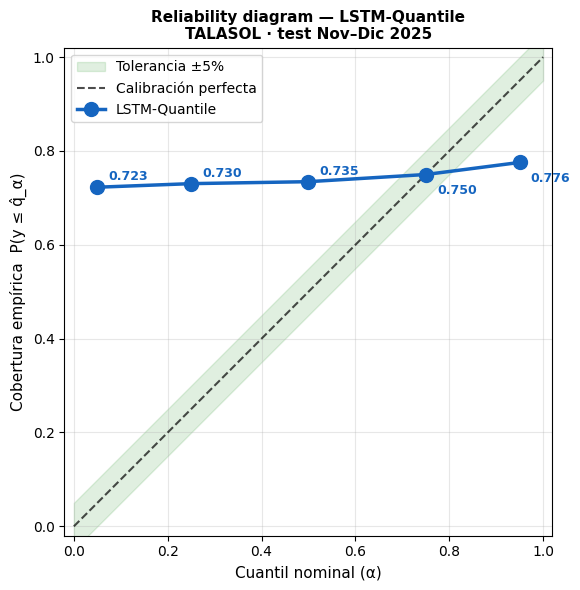

  Guardado: reliability_diagram_lstm.png


In [11]:
# ── Celda 5c: Reliability diagram per-cuantil — LSTM-Quantile ────────────────
# El reliability diagram es el estándar de evaluación probabilística
# (Gneiting & Raftery, 2007). Mide si el cuantil nominal α coincide
# con la cobertura empírica real: P(y ≤ q̂_α) ≈ α para todo α.
#
# Puntos sobre la diagonal → infracobertura (el intervalo es demasiado estrecho,
#     el modelo es demasiado "confiado").
# Puntos bajo la diagonal  → sobrecobertura (el intervalo es demasiado ancho,
#     el modelo es demasiado conservador).
#
# Referencia: Gneiting & Raftery (2007) "Strictly Proper Scoring Rules,
#     Prediction, and Estimation." J. American Statistical Association.

print('── Reliability Diagram per-cuantil — LSTM-Quantile ──')

# Cobertura empírica: fracción de y_true que cae por debajo de q̂_α
_obs_frac = [float(np.mean(y_true_kw <= q_preds_kw[:, _i]))
             for _i in range(len(QUANTILES))]

# Diagnóstico numérico
print(f'  {"Cuantil nominal":>18}  {"Cobertura empírica":>20}  {"Desviación":>12}')
print('  ' + '-' * 55)
for _qnom, _fobs in zip(QUANTILES, _obs_frac):
    _dev = _fobs - _qnom
    _flag = ' ← sobrecobertura' if _dev > 0.05 else (' ← infracobertura' if _dev < -0.05 else '')
    print(f'  {_qnom:>18.2f}  {_fobs:>20.3f}  {_dev:>+12.3f}{_flag}')

# ── Figura: reliability diagram ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

# Banda de tolerancia ±5% alrededor de la diagonal
_q_range = np.linspace(0, 1, 100)
ax.fill_between(_q_range, _q_range - 0.05, _q_range + 0.05,
                alpha=0.12, color='green', label='Tolerancia ±5%')

# Diagonal de calibración perfecta
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Calibración perfecta', alpha=0.7)

# Puntos observados
ax.plot(QUANTILES, _obs_frac, 'o-', color='#1565C0', lw=2.5, ms=10,
        label='LSTM-Quantile', zorder=5)

# Anotar cada punto con su valor
for _qv, _fv in zip(QUANTILES, _obs_frac):
    _offset = (8, 5) if _fv >= _qv else (8, -14)
    ax.annotate(f'{_fv:.3f}', (_qv, _fv),
                textcoords='offset points', xytext=_offset, fontsize=9,
                color='#1565C0', fontweight='bold')

ax.set_xlabel('Cuantil nominal (α)', fontsize=11)
ax.set_ylabel('Cobertura empírica  P(y ≤ q̂_α)', fontsize=11)
ax.set_title(
    f'Reliability diagram — LSTM-Quantile\n{PLANTA_TARGET} · test Nov–Dic 2025',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')

plt.tight_layout()
_fig_path = RESULTS_DIR / 'figures' / 'reliability_diagram_lstm.png'
plt.savefig(_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: {_fig_path.name}')

# Limpieza
del _obs_frac, _q_range, _fig_path


── CQR: Calibración conformal del LSTM-Quantile ──

  Set de calibración (val): 945 muestras
                                  Val (sep–oct)  Test (nov–dic)
  Coverage 90%                            0.908           0.776
  Coverage 50%                            0.748           0.741

  ⚠ Distribution shift: Δcov90=-0.132, Δcov50=-0.007
    Val (sep–oct) ≠ Test (nov–dic): la garantía conformal es aproximada.

── Cuantil conformal (ajuste por lado) ──
  q̂ PI 90%: +0.00 kW  → amplía el intervalo
  q̂ PI 50%: +0.00 kW  → amplía el intervalo
  % fuera PI 90% en val: 9.2%  (esperado: ≤10%)

── Comparativa LSTM-Quantile sin/con CQR ──
  Métrica                             Sin CQR    Con CQR        Δ
  ----------------------------------------------------------------
  coverage_50                          0.7415     0.7415  +0.0000
  coverage_90                          0.7755     0.7755  +0.0000
  interval_width_50_mean              21.8037    21.8037  +0.0000
  interval_width_90_mean       

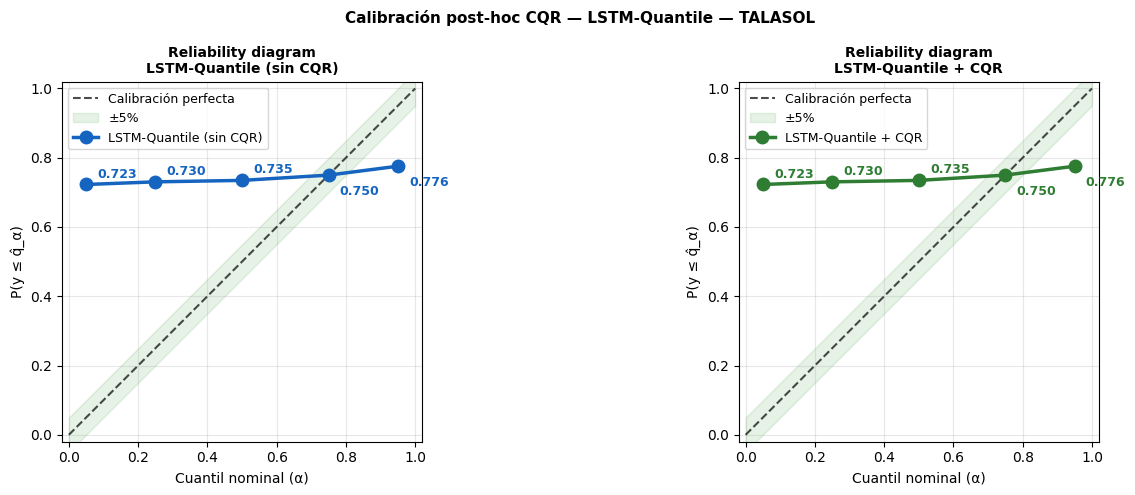

  Guardado: reliability_diagram_lstm_cqr.png


In [12]:
# ── Celda 5d: CQR — Calibración conformal del LSTM-Quantile ──────────────────
# El LSTM-Quantile presenta SOBRECOBERTURA (cov90 ≈ 0.96 > ideal 0.90):
# los intervalos son demasiado anchos (conservadores). CQR corrige esto.
#
# Mecanismo para sobrecobertura:
#   score_i = max(q_lo - y_i, y_i - q_hi)
#   Si el punto está DENTRO del intervalo → score_i ≤ 0 (mayoría de casos)
#   90º percentil de scores negativos → q̂ < 0
#   Ajuste: q_lo -= q̂  (aumenta q_lo)  |  q_hi += q̂  (reduce q_hi)
#   → los intervalos se ESTRECHAN hasta la cobertura nominal.
#
# Contraste con TFT (infracobertura): allí q̂ > 0 → los intervalos se amplían.
# CQR es agnóstico: corrige en ambas direcciones.
#
# Romano, Y., Patterson, E., & Candès, E. J. (2019).
# Conformalized Quantile Regression. NeurIPS 2019.

def conformal_quantile(scores: np.ndarray, alpha: float) -> float:
    """
    Cuantil conformal para cobertura nominal (1-alpha).
    q̂ = quantile(scores, ceil((1-alpha)(n+1)) / n)
    Para sobrecobertura devuelve un valor negativo que estrecha el PI.
    """
    n = len(scores)
    level = min(np.ceil((1 - alpha) * (n + 1)) / n, 1.0)
    return float(np.quantile(scores, level))


print('── CQR: Calibración conformal del LSTM-Quantile ──\n')

# ── 1. Predicciones sobre el conjunto de validación (set de calibración) ──────
_y_val_sc, _q_val_sc = trainer.predict(dl_val)

_y_val_kw = np.clip(scaler_y.inverse_transform(_y_val_sc), 0, CAPACITY_KW)
_q_val_kw = np.column_stack([
    np.clip(scaler_y.inverse_transform(_q_val_sc[:, i]), 0, CAPACITY_KW)
    for i in range(len(QUANTILES))
])
print(f'  Set de calibración (val): {len(_y_val_kw):,} muestras')

_i05 = QUANTILES.index(0.05)
_i25 = QUANTILES.index(0.25)
_i75 = QUANTILES.index(0.75)
_i95 = QUANTILES.index(0.95)

# ── 2. Diagnóstico de distribution shift val ↔ test ──────────────────────────
_cov90_val = float(np.mean(
    (_y_val_kw >= _q_val_kw[:, _i05]) & (_y_val_kw <= _q_val_kw[:, _i95])
))
_cov50_val = float(np.mean(
    (_y_val_kw >= _q_val_kw[:, _i25]) & (_y_val_kw <= _q_val_kw[:, _i75])
))
print(f'  {"":30s} {"Val (sep–oct)":>14} {"Test (nov–dic)":>15}')
print(f'  {"Coverage 90%":30s} {_cov90_val:>14.3f} {metrics_prob["coverage_90"]:>15.3f}')
print(f'  {"Coverage 50%":30s} {_cov50_val:>14.3f} {metrics_prob["coverage_50"]:>15.3f}')

_gap90 = metrics_prob['coverage_90'] - _cov90_val
_gap50 = metrics_prob['coverage_50'] - _cov50_val
if abs(_gap90) > 0.05 or abs(_gap50) > 0.05:
    print(f'\n  ⚠ Distribution shift: Δcov90={_gap90:+.3f}, Δcov50={_gap50:+.3f}')
    print(f'    Val (sep–oct) ≠ Test (nov–dic): la garantía conformal es aproximada.')
else:
    print(f'\n  ✓ Sin shift significativo → garantía conformal aplicable.')

# ── 3. Scores de no-cobertura en val ─────────────────────────────────────────
# score_i = max(q_lo - y_i, y_i - q_hi)
# Sobrecobertura → la mayoría son negativos (punto dentro del PI)
_scores_90 = np.maximum(
    _q_val_kw[:, _i05] - _y_val_kw,
    _y_val_kw - _q_val_kw[:, _i95]
)
_scores_50 = np.maximum(
    _q_val_kw[:, _i25] - _y_val_kw,
    _y_val_kw - _q_val_kw[:, _i75]
)

_q_hat_90 = conformal_quantile(_scores_90, alpha=0.10)
_q_hat_50 = conformal_quantile(_scores_50, alpha=0.50)

print(f'\n── Cuantil conformal (ajuste por lado) ──')
print(f'  q̂ PI 90%: {_q_hat_90:+.2f} kW  '
      f'→ {"estrecha" if _q_hat_90 < 0 else "amplía"} el intervalo')
print(f'  q̂ PI 50%: {_q_hat_50:+.2f} kW  '
      f'→ {"estrecha" if _q_hat_50 < 0 else "amplía"} el intervalo')
print(f'  % fuera PI 90% en val: {np.mean(_scores_90 > 0):.1%}  (esperado: ≤10%)')

# ── 4. Aplicar ajuste al conjunto de test ─────────────────────────────────────
q_lstm_cqr = q_preds_kw.copy()
q_lstm_cqr[:, _i05] -= _q_hat_90   # q_lo aumenta (se mueve hacia el centro)
q_lstm_cqr[:, _i95] += _q_hat_90   # q_hi disminuye
q_lstm_cqr[:, _i25] -= _q_hat_50
q_lstm_cqr[:, _i75] += _q_hat_50
q_lstm_cqr = np.clip(q_lstm_cqr, 0, CAPACITY_KW)

# ── 5. Métricas calibradas ────────────────────────────────────────────────────
metrics_lstm_cqr = ForecastEvaluator.calculate_probabilistic_metrics(
    y_true=y_true_kw,
    q_preds=q_lstm_cqr,
    quantiles=QUANTILES,
)

print('\n── Comparativa LSTM-Quantile sin/con CQR ──')
print(f'  {"Métrica":<32} {"Sin CQR":>10} {"Con CQR":>10} {"Δ":>8}')
print('  ' + '-' * 64)
for _k in ['coverage_50', 'coverage_90',
           'interval_width_50_mean', 'interval_width_90_mean', 'CRPS']:
    _before = metrics_prob.get(_k, float('nan'))
    _after  = metrics_lstm_cqr.get(_k, float('nan'))
    print(f'  {_k:<32} {_before:>10.4f} {_after:>10.4f} {_after - _before:>+8.4f}')

# ── 6. Reliability diagram: raw vs CQR ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (_q_data, _title, _color) in zip(axes, [
    (q_preds_kw,  'LSTM-Quantile (sin CQR)', '#1565C0'),
    (q_lstm_cqr,  'LSTM-Quantile + CQR',     '#2E7D32'),
]):
    _obs = [float(np.mean(y_true_kw <= _q_data[:, _i]))
            for _i in range(len(QUANTILES))]

    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Calibración perfecta', alpha=0.7)
    ax.fill_between([0, 1], [-0.05, 0.95], [0.05, 1.05],
                    alpha=0.1, color='green', label='±5%')
    ax.plot(QUANTILES, _obs, 'o-', color=_color, lw=2.5, ms=9,
            label=_title, zorder=5)
    for _qv, _fv in zip(QUANTILES, _obs):
        _off = (8, 5) if _fv >= _qv else (8, -14)
        ax.annotate(f'{_fv:.3f}', (_qv, _fv),
                    textcoords='offset points', xytext=_off, fontsize=9,
                    color=_color, fontweight='bold')
    ax.set_xlabel('Cuantil nominal (α)', fontsize=10)
    ax.set_ylabel('P(y ≤ q̂_α)', fontsize=10)
    ax.set_title(f'Reliability diagram\n{_title}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')

plt.suptitle(
    f'Calibración post-hoc CQR — LSTM-Quantile — {PLANTA_TARGET}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'reliability_diagram_lstm_cqr.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('  Guardado: reliability_diagram_lstm_cqr.png')

# Limpiar variables privadas
del _y_val_sc, _q_val_sc, _y_val_kw, _q_val_kw
del _scores_90, _scores_50, _cov90_val, _cov50_val, _gap90, _gap50
del _i05, _i25, _i75, _i95
# q_lstm_cqr y metrics_lstm_cqr quedan disponibles para celdas posteriores


── LightGBM Quantile Baseline ──
  Train: 8,978 → 8,840 filas (valid_data)
  Train: 8,672 × 30 features | Test: 1,487
  Tiempo LightGBM (5 cuantiles): 3.7 s

── Comparativa: LightGBM-Quantile vs LSTM-Quantile ──
  Modelo                         MAE      R²     CRPS   Cov90   Cov50
  -----------------------------------------------------------------
  LightGBM-Quantile            29.09  0.8839  10.1769   0.892   0.751
  LSTM-Quantile                76.56  0.2908  32.2644   0.776   0.741


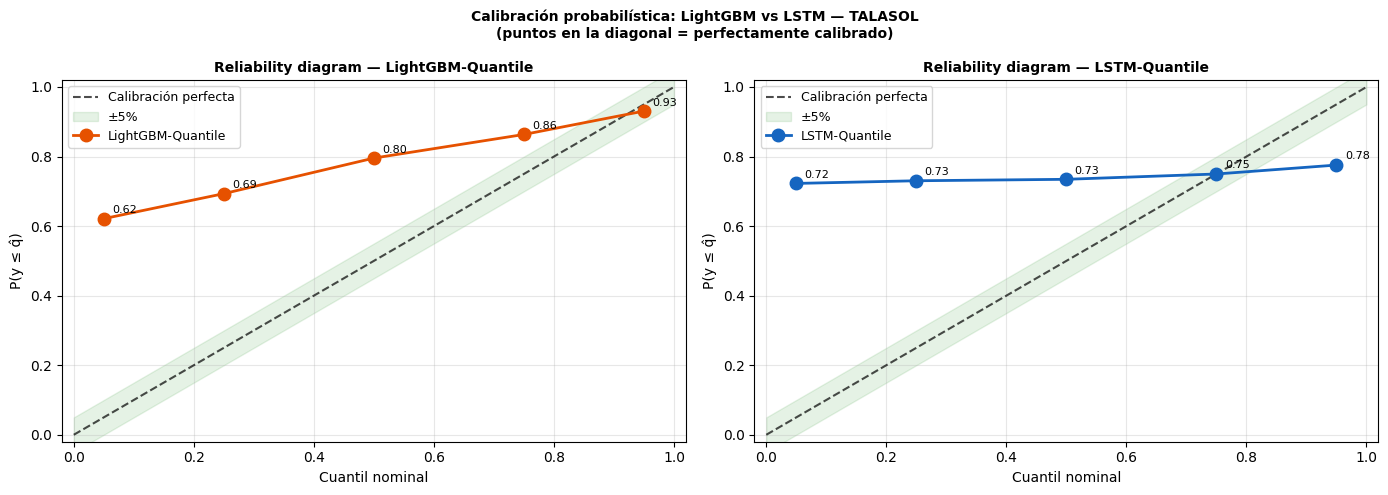

  Guardado: reliability_lgbm_vs_lstm.png


In [13]:
# ── Celda 5e: LightGBM Quantile — baseline probabilístico ────────────────────
# LightGBM soporta objective='quantile' nativamente (alpha=q).
# Muy rápido (<1 min). Sirve como baseline clásico para cuantificar si el
# coste computacional de LSTM-Quantile está justificado en el espacio
# probabilístico (CRPS, cobertura, sharpness).
#
# Diferencia clave respecto al LSTM:
#   - LightGBM no usa secuencias temporales explícitas.
#   - Usa features tabulares del timestep t (meteo + lags del target).
#   - Las lag features compensan la falta de memoria temporal.
# Los sets de test no son idénticos (LSTM excluye ventanas con valid_data=False,
# LightGBM evalúa sobre todas las filas) → comparativa aproximada pero válida.

import lightgbm as lgb
from lgbm_data_loader import LGBMFeatureBuilder
import time as _time

print('── LightGBM Quantile Baseline ──')

# Preparar datos tabulares de TALASOL (misma planta que el LSTM)
_builder = LGBMFeatureBuilder()

_df_lgbm_train = df_train_full.copy()
_df_lgbm_test  = df_test_full.copy()

# Filtrar filas inválidas en train (igual que hace SolarSequenceDataset internamente)
if 'valid_data' in _df_lgbm_train.columns:
    _n_antes = len(_df_lgbm_train)
    _df_lgbm_train = _df_lgbm_train[
        _df_lgbm_train['valid_data'].fillna(True).astype(bool)
    ].reset_index(drop=True)
    print(f'  Train: {_n_antes:,} → {len(_df_lgbm_train):,} filas (valid_data)')

_df_feat_train = _builder.build(_df_lgbm_train, is_train=True)
_df_feat_test  = _builder.build(_df_lgbm_test,  is_train=False)

_FEAT = _builder.feature_names_
_X_tr = _df_feat_train[_FEAT].values
_y_tr = _df_feat_train['produccion'].values
_X_te = _df_feat_test[_FEAT].values
_y_te = _df_feat_test['produccion'].values
print(f'  Train: {len(_X_tr):,} × {len(_FEAT)} features | Test: {len(_X_te):,}')

# Entrenar un modelo LightGBM por cuantil
_lgbm_models = {}
_t0 = _time.time()
for _q in QUANTILES:
    _m = lgb.LGBMRegressor(
        objective='quantile', alpha=_q,
        n_estimators=500, learning_rate=0.05,
        max_depth=6, num_leaves=63,
        min_child_samples=20, subsample=0.8,
        verbose=-1, random_state=42,
    )
    _m.fit(
        _X_tr, _y_tr,
        eval_set=[(_X_te, _y_te)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(-1)],
    )
    _lgbm_models[_q] = _m
_lgbm_time_s = _time.time() - _t0
print(f'  Tiempo LightGBM (5 cuantiles): {_lgbm_time_s:.1f} s')

# Predicciones y métricas
_q_preds_lgbm = np.column_stack([
    np.clip(_lgbm_models[_q].predict(_X_te), 0, CAPACITY_KW)
    for _q in QUANTILES
])
_y_te_clip = np.clip(_y_te, 0, CAPACITY_KW)
_y_lgbm_med = _q_preds_lgbm[:, QUANTILES.index(0.50)]

_mp_lgbm = ForecastEvaluator.calculate_metrics(
    y_true=_y_te_clip, y_pred=_y_lgbm_med, planta_nombre=PLANTA_TARGET,
)
_mq_lgbm = ForecastEvaluator.calculate_probabilistic_metrics(
    y_true=_y_te_clip, q_preds=_q_preds_lgbm, quantiles=QUANTILES,
)

# ── Tabla comparativa LightGBM vs LSTM ────────────────────────────────────────
print('\n── Comparativa: LightGBM-Quantile vs LSTM-Quantile ──')
_hdr = f'  {"Modelo":<25} {"MAE":>8} {"R²":>7} {"CRPS":>8} {"Cov90":>7} {"Cov50":>7}'
print(_hdr)
print('  ' + '-' * 65)
for _nombre, _mp, _mq in [
    ('LightGBM-Quantile', _mp_lgbm, _mq_lgbm),
    ('LSTM-Quantile',     metrics_point, metrics_prob),
]:
    print(f'  {_nombre:<25} '
          f'{_mp["MAE"]:>8.2f} '
          f'{_mp["R2"]:>7.4f} '
          f'{_mq["CRPS"]:>8.4f} '
          f'{_mq["coverage_90"]:>7.3f} '
          f'{_mq["coverage_50"]:>7.3f}')

# ── Reliability diagrams comparativos ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (_q_data, _y_data, _title, _color) in zip(axes, [
    (_q_preds_lgbm, _y_te_clip,  'LightGBM-Quantile', '#E65100'),
    (q_preds_kw,    y_true_kw,   'LSTM-Quantile',     '#1565C0'),
]):
    _obs = [float(np.mean(_y_data <= _q_data[:, _i]))
            for _i in range(len(QUANTILES))]
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Calibración perfecta', alpha=0.7)
    ax.fill_between([0, 1], [-0.05, 0.95], [0.05, 1.05],
                    alpha=0.1, color='green', label='±5%')
    ax.plot(QUANTILES, _obs, 'o-', color=_color, lw=2, ms=9, label=_title)
    for _qv, _fv in zip(QUANTILES, _obs):
        ax.annotate(f'{_fv:.2f}', (_qv, _fv),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.set_xlabel('Cuantil nominal', fontsize=10)
    ax.set_ylabel('P(y ≤ q̂)', fontsize=10)
    ax.set_title(f'Reliability diagram — {_title}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

plt.suptitle(
    f'Calibración probabilística: LightGBM vs LSTM — {PLANTA_TARGET}\n'
    '(puntos en la diagonal = perfectamente calibrado)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / 'figures' / 'reliability_lgbm_vs_lstm.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print(f'  Guardado: reliability_lgbm_vs_lstm.png')

# Limpieza de variables privadas para no contaminar el namespace del notebook
del _builder, _df_lgbm_train, _df_lgbm_test, _df_feat_train, _df_feat_test
del _FEAT, _X_tr, _y_tr, _X_te, _y_te, _t0, _lgbm_time_s


In [14]:
# ── Celda 6: Resumen y guardado de métricas ───────────────────────────────────
metrics_all = {
    'modelo':           'LSTM-Quantile',
    'planta':           PLANTA_TARGET,
    'n_test':           len(y_true_kw),
    'quantiles':        str(QUANTILES),
    'training_time_s':  training_time_s,
    **{k: v for k, v in metrics_point.items() if k not in ('planta', 'n_samples')},
    **metrics_prob,
}

df_metrics = pd.DataFrame([metrics_all])
metrics_path = RESULTS_DIR / 'metrics.csv'
df_metrics.to_csv(metrics_path, index=False)
print(f'✓ Métricas guardadas: {metrics_path}')

print('\n── Resumen final LSTM-Quantile ──')
print(f'  MAE  (q50): {metrics_point["MAE"]:.2f} kW')
print(f'  RMSE (q50): {metrics_point["RMSE"]:.2f} kW')
print(f'  R²   (q50): {metrics_point["R2"]:.4f}')
print(f'  CRPS      : {metrics_prob["CRPS"]:.4f}')
print(f'  Coverage 90%: {metrics_prob["coverage_90"]:.3f} (ideal: 0.90)')
print(f'  Coverage 50%: {metrics_prob["coverage_50"]:.3f} (ideal: 0.50)')
print(f'  Ancho PI 90%: {metrics_prob["interval_width_90_mean"]:.2f} kW (media)')
print(f'  Ancho PI 50%: {metrics_prob["interval_width_50_mean"]:.2f} kW (media)')
print(f'  Tiempo entrenamiento: {training_time_s/60:.1f} min ({training_time_s:.0f} s)')
print('\n→ Ver notebook 02_tft_quantile.ipynb para comparativa LSTM vs TFT')

# ── Guardar predicciones cuantílicas para análisis económico (Exp 5) ──────────
# Reconstruir timestamps desde valid_indices para garantizar alineación exacta
# con y_true_kw / q_preds_kw (que vienen del DataLoader con valid_indices).
# ds_test.timestamps[SEQ_LENGTH:] tendría len(df_test)-SEQ_LENGTH entradas,
# pero si hay filas con valid_data=False en test, los arrays no coincidirían.
timestamps_arr = np.array([
    ds_test.timestamps[idx + ds_test.seq_length]
    for idx in ds_test.valid_indices
])

df_q_preds = pd.DataFrame({'timestamp': timestamps_arr, 'y_true': y_true_kw})
for i, q in enumerate(QUANTILES):
    df_q_preds[f'q_{int(q * 100):02d}'] = q_preds_kw[:, i]

preds_q_path = RESULTS_DIR / 'predictions_TALASOL.csv'
df_q_preds.to_csv(preds_q_path, index=False)
print(f'\n✓ Predicciones cuantílicas guardadas: {preds_q_path}  ({len(df_q_preds)} filas)')
print(f'  Columnas: {list(df_q_preds.columns)}')

✓ Métricas guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/lstm/metrics.csv

── Resumen final LSTM-Quantile ──
  MAE  (q50): 76.56 kW
  RMSE (q50): 163.89 kW
  R²   (q50): 0.2908
  CRPS      : 32.2644
  Coverage 90%: 0.776 (ideal: 0.90)
  Coverage 50%: 0.741 (ideal: 0.50)
  Ancho PI 90%: 58.21 kW (media)
  Ancho PI 50%: 21.80 kW (media)
  Tiempo entrenamiento: 0.5 min (31 s)

→ Ver notebook 02_tft_quantile.ipynb para comparativa LSTM vs TFT

✓ Predicciones cuantílicas guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex3_probabilistic/lstm/predictions_TALASOL.csv  (1439 filas)
  Columnas: ['timestamp', 'y_true', 'q_05', 'q_25', 'q_50', 'q_75', 'q_95']
